In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

In [2]:
root = Path("../..")

In [3]:
DATASET_DIR = root / "data" / "processed"
INPUT_DATASET_PATH = DATASET_DIR / "processed_df_0.csv"
OUTPUT_DATASET_PATH = DATASET_DIR / "processed_df_1.csv"
DATASET_DIR.exists(), INPUT_DATASET_PATH.exists() # have to be True

(True, True)

In [4]:
df = pd.read_csv(INPUT_DATASET_PATH)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   role             750 non-null    str  
 1   message_number   750 non-null    int64
 2   sentence_number  750 non-null    int64
 3   sentence         750 non-null    str  
 4   tag              750 non-null    str  
 5   dialogue_number  750 non-null    int64
dtypes: int64(3), str(3)
memory usage: 35.3 KB


In [5]:
df = df.sort_values(by=["dialogue_number", "message_number", "sentence_number"]).reset_index(drop=True)

In [6]:
# replacing multiple whitespaces with single + removing leading/training whitespaces
df["sentence_clean"] = df["sentence"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   role             750 non-null    str  
 1   message_number   750 non-null    int64
 2   sentence_number  750 non-null    int64
 3   sentence         750 non-null    str  
 4   tag              750 non-null    str  
 5   dialogue_number  750 non-null    int64
 6   sentence_clean   750 non-null    str  
dtypes: int64(3), str(4)
memory usage: 41.1 KB


In [8]:
starts = df.groupby("dialogue_number").head(1)

print(starts[["dialogue_number", "role", "message_number", "sentence_number", "sentence", "tag"]])

     dialogue_number           role  message_number  sentence_number  \
0                  0      Proponent               0                1   
15                 1      Proponent               0                1   
31                 2      Proponent               0                0   
46                 3      Proponent               0                1   
63                 4      Proponent               0                1   
76                 5      Proponent               0                1   
89                 6  Domain Expert               1                1   
102                7      Proponent               0                0   
114                8  Domain Expert               1                1   
128                9      Proponent               0                0   
143               10      Proponent               0                1   
158               11  Domain Expert               1                1   
183               12      Proponent               0             

In [9]:
df_temp = df.copy(deep=True)

In [10]:
df_temp["sentence"] = df_temp["sentence"].astype(str).str.strip()

empty_sentences = df_temp[df_temp["sentence"].eq("")]
print("Empty sentences:", len(empty_sentences))

Empty sentences: 0


In [11]:
duplicates = df_temp.duplicated(
    subset=["dialogue_number", "role", "message_number", "sentence_number", "sentence", "tag"]
)

print(df_temp[duplicates])
# these seem okay because they are different messages

          role  message_number  sentence_number      sentence         tag  \
160  Proponent               2                0  Yes, please.  reply_info   
175  Proponent              10                0  Yes, please.  reply_info   

     dialogue_number sentence_clean  
160               11   yes, please.  
175               11   yes, please.  


In [12]:
print(pd.crosstab(df_temp["role"], df_temp["tag"], normalize="index") * 100)

tag             ask_info  ask_rebuttal  ask_suggestion  give_opinion  \
role                                                                   
Domain Expert   0.982801      6.879607        7.616708     11.793612   
Proponent      63.265306      6.122449        1.166181     21.865889   

tag            reply_info  
role                       
Domain Expert   72.727273  
Proponent        7.580175  


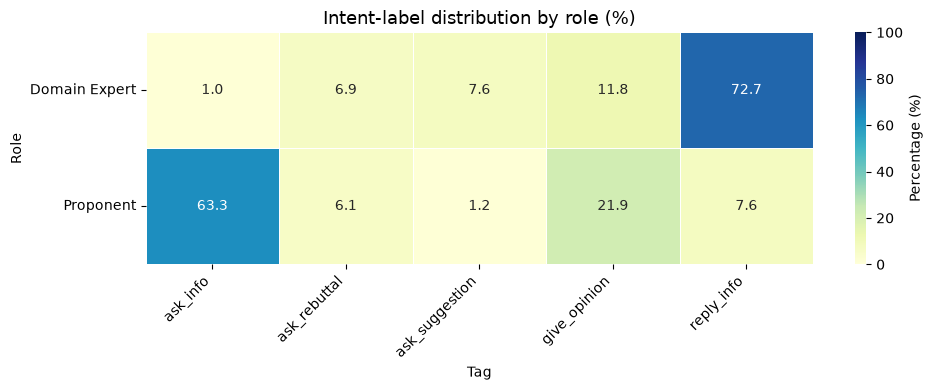

In [13]:
dist = pd.crosstab(df_temp["role"], df_temp["tag"], normalize="index") * 100

plt.figure(figsize=(10, 4))

ax = sns.heatmap(
    dist,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Percentage (%)"},
    vmin=0,
    vmax=100
)

plt.title("Intent-label distribution by role (%)", fontsize=13)
plt.xlabel("Tag")
plt.ylabel("Role")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
seq_lengths = df_temp.groupby("dialogue_number").size()

print(seq_lengths.describe())
print("Very short sequences:")
print(seq_lengths[seq_lengths <= 1])
# oh great no one word sequences XD

count    41.000000
mean     18.292683
std       5.163545
min      12.000000
25%      15.000000
50%      16.000000
75%      21.000000
max      32.000000
dtype: float64
Very short sequences:
Series([], dtype: int64)


In [15]:
df.to_csv(OUTPUT_DATASET_PATH, index=False)